In [1]:
# CELDA 1: Importamos las herramientas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
import warnings

# Configuraciones visuales para la presentación
warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# CELDA 2: Carga de datos curados
# Explicación para el oral: Aprendimos que mezclar Tiers ensucia el modelo. 
# Usamos solo Tier 1 y filtramos is_total == False para evitar datos corruptos de la API.

df_tier1 = pd.read_csv('cs2_tier1_games.csv')
df_tier1 = df_tier1[df_tier1['is_total'] == False]
df_tier1['datetime'] = pd.to_datetime(df_tier1['datetime'], errors='coerce')

print(f"Total de mapas de Tier 1 limpios a analizar: {len(df_tier1)}")

Total de mapas de Tier 1 limpios a analizar: 6162


In [3]:
# CELDA 3: Extraemos el rendimiento individual por partida
# Simulamos el monitoreo en tiempo real: ¿Alguien la rompió en este mapa específico?

lista_partidas = []

for equipo in [1, 2]:
    for slot in [1, 2, 3, 4, 5]:
        col_jug = f'team{equipo}_player{slot}'
        col_k = f'team{equipo}_player{slot}_kills'
        col_d = f'team{equipo}_player{slot}_deaths'
        col_adr = f'team{equipo}_player{slot}_adr'
        
        if all(c in df_tier1.columns for c in [col_jug, col_k, col_d, col_adr]):
            temp = df_tier1[[col_jug, col_k, col_d, col_adr]].dropna().copy()
            temp.columns = ['Jugador', 'Kills', 'Deaths', 'ADR']
            lista_partidas.append(temp)

df_partidas = pd.concat(lista_partidas, ignore_index=True)
df_partidas = df_partidas[df_partidas['Deaths'] > 0] # Evitar división por cero
df_partidas['K/D Ratio'] = df_partidas['Kills'] / df_partidas['Deaths']

print(f"Rendimientos individuales en mapas extraídos: {len(df_partidas)}")

Rendimientos individuales en mapas extraídos: 60144


In [4]:
# CELDA 4: Aplicamos Isolation Forest (Diapositiva 10)
# Buscamos anomalías bidimensionales: Jugadores con K/D y ADR extremadamente raros en una partida.

X_basico = df_partidas[['K/D Ratio', 'ADR']]

# Contaminación 0.01 = Buscamos el 1% más anómalo de las partidas
modelo_basico = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
df_partidas['Anomalia'] = modelo_basico.fit_predict(X_basico)

print("Distribución de datos detectados (1 = Normal, -1 = Anomalía):")
print(df_partidas['Anomalia'].value_counts())

Distribución de datos detectados (1 = Normal, -1 = Anomalía):
Anomalia
 1    59543
-1      601
Name: count, dtype: int64


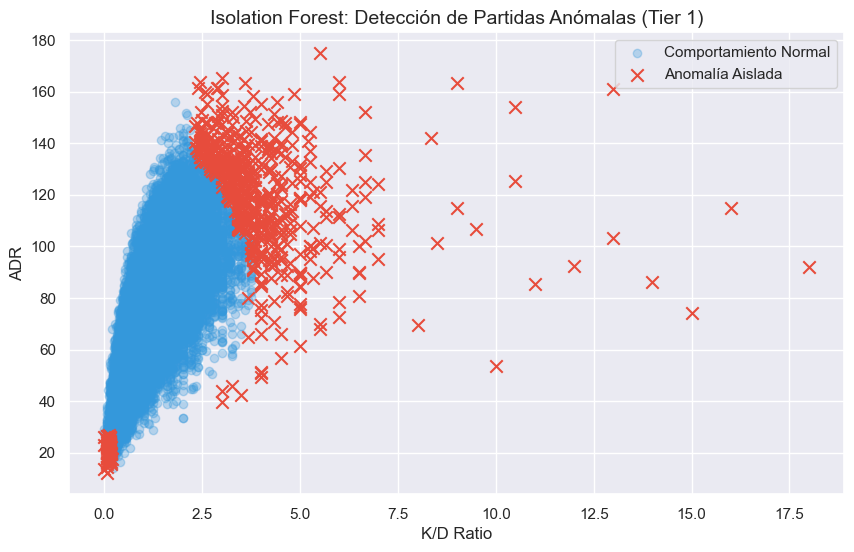

In [5]:
# CELDA 5: Gráfico del algoritmo aislando outliers
normales = df_partidas[df_partidas['Anomalia'] == 1]
anomalos = df_partidas[df_partidas['Anomalia'] == -1]

plt.scatter(normales['K/D Ratio'], normales['ADR'], c='#3498db', alpha=0.3, label='Comportamiento Normal')
plt.scatter(anomalos['K/D Ratio'], anomalos['ADR'], c='#e74c3c', marker='x', s=80, label='Anomalía Aislada')

plt.title('Isolation Forest: Detección de Partidas Anómalas (Tier 1)', fontsize=14)
plt.xlabel('K/D Ratio')
plt.ylabel('ADR')
plt.legend()
plt.show()

In [6]:
# CELDA 6: Transición a un modelo potente
# Explicación: Para evitar "Alert Fatigue" (Diap. 15), no miramos una partida. 
# Consolidamos el historial completo de cada jugador por año con 4 variables clave.

lista_perfiles = []

for equipo in [1, 2]:
    for slot in [1, 2, 3, 4, 5]:
        c_jug = f'team{equipo}_player{slot}'
        c_k = f'team{equipo}_player{slot}_kills'
        c_d = f'team{equipo}_player{slot}_deaths'
        c_a = f'team{equipo}_player{slot}_assists'
        c_adr = f'team{equipo}_player{slot}_adr'
        c_kast = f'team{equipo}_player{slot}_kast'
        
        cols = ['datetime', c_jug, c_k, c_d, c_a, c_adr, c_kast]
        if all(c in df_tier1.columns for c in cols):
            temp = df_tier1[cols].dropna().copy()
            temp['Año'] = temp['datetime'].dt.year
            temp = temp[['Año', c_jug, c_k, c_d, c_a, c_adr, c_kast]]
            temp.columns = ['Año', 'Jugador', 'Kills', 'Deaths', 'Assists', 'ADR', 'KAST']
            lista_perfiles.append(temp)

historial_t1 = pd.concat(lista_perfiles, ignore_index=True)
print("Datos multidimensionales extraídos con éxito.")

Datos multidimensionales extraídos con éxito.


In [7]:
# CELDA 7: Creamos el perfil del jugador consolidado
perfiles_t1 = historial_t1.groupby(['Año', 'Jugador']).agg(
    Mapas_Jugados=('Kills', 'count'),
    Promedio_Kills=('Kills', 'mean'),
    Promedio_Deaths=('Deaths', 'mean'),
    Promedio_Assists=('Assists', 'mean'),
    Promedio_ADR=('ADR', 'mean'),
    Promedio_KAST=('KAST', 'mean')
).reset_index()

# Filtro de consistencia: Mínimo 20 mapas en el año para ser considerado en la Elite
perfiles_t1 = perfiles_t1[perfiles_t1['Mapas_Jugados'] >= 20]
perfiles_t1['K/D_Historico'] = perfiles_t1['Promedio_Kills'] / perfiles_t1['Promedio_Deaths']
perfiles_t1 = perfiles_t1.dropna()

print(f"Perfiles únicos de jugadores consistentes por año: {len(perfiles_t1)}")

Perfiles únicos de jugadores consistentes por año: 734


In [8]:
# CELDA 8: Isolation Forest Avanzado
# Le pasamos al algoritmo 4 variables simultáneas para que detecte la "firma" del jugador.

X_avanzado = perfiles_t1[['K/D_Historico', 'Promedio_ADR', 'Promedio_KAST', 'Promedio_Assists']]

# Contaminación 0.05: Buscamos el 5% del ecosistema con comportamiento más desviado
modelo_avanzado = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
perfiles_t1['Anomalia_Sistemica'] = modelo_avanzado.fit_predict(X_avanzado)

# Filtramos las anomalías hacia arriba (Los mejores, no los peores)
elite_anomala = perfiles_t1[(perfiles_t1['Anomalia_Sistemica'] == -1) & (perfiles_t1['K/D_Historico'] > 1.05)]

print("Modelo entrenado y anomalías de élite aisladas.")

Modelo entrenado y anomalías de élite aisladas.


In [9]:
# CELDA 9: Filtramos los resultados matemáticos para un año específico
AÑO_A_ANALIZAR = 2023

resultados_2023 = elite_anomala[elite_anomala['Año'] == AÑO_A_ANALIZAR].copy()

# Ordenamos por las métricas de mayor impacto para ver a los outliers más extremos
resultados_2023 = resultados_2023.sort_values(
    by=['K/D_Historico', 'Promedio_ADR'], ascending=[False, False]
)

print(f"Jugadores detectados como anomalías matemáticas en {AÑO_A_ANALIZAR}: {len(resultados_2023)}")

Jugadores detectados como anomalías matemáticas en 2023: 3


In [10]:
# CELDA 10: El momento de la verdad en la presentación
# Comparamos a quiénes aisló el algoritmo vs quiénes coronó HLTV.

print(f"--- LA ÉLITE ANÓMALA SEGÚN ISOLATION FOREST ({AÑO_A_ANALIZAR}) ---")
print("*(Si la curación de datos fue correcta, estos nombres deberían coincidir con el Top 20 HLTV)*\n")

columnas_mostrar = ['Jugador', 'Mapas_Jugados', 'K/D_Historico', 'Promedio_ADR', 'Promedio_KAST']
display_df = resultados_2023[columnas_mostrar]

# Mostramos el Top 15 resultante
display_df.head(15)

--- LA ÉLITE ANÓMALA SEGÚN ISOLATION FOREST (2023) ---
*(Si la curación de datos fue correcta, estos nombres deberían coincidir con el Top 20 HLTV)*



,Jugador,Mapas_Jugados,K/D_Historico,Promedio_ADR,Promedio_KAST
36,"Jame (Ali Djami), RU",32,1.327027,68.384375,75.903125
180,"ropz (Robin Kool), EE",40,1.261023,82.245000,76.087500
23,"EliGE (Jonathan Jablonowski), US",21,1.231544,89.780952,72.038095


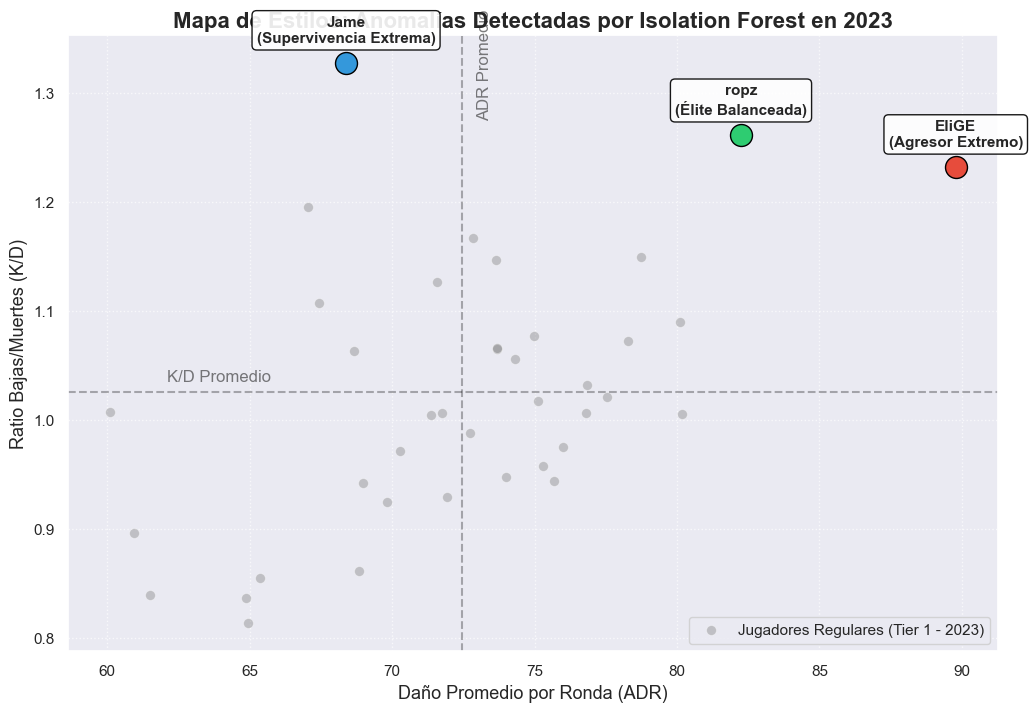

In [23]:
# CELDA 12: Visualización Explicativa de las Anomalías (Solo 2023 y con Nombres)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LIMITADO A 2023: Filtramos todos los jugadores de 2023 para usarlos de fondo
df_2023 = perfiles_t1[perfiles_t1['Año'] == AÑO_A_ANALIZAR].copy()

plt.figure(figsize=(12, 8))

# 2. LOS "OTROS": Graficamos a TODOS los jugadores como puntos grises anónimos
sns.scatterplot(
    data=df_2023, 
    x='Promedio_ADR', 
    y='K/D_Historico', 
    color='gray', 
    alpha=0.4, 
    label='Jugadores Regulares (Tier 1 - 2023)',
    s=50
)

# 3. LAS ANOMALÍAS CON NOMBRE (Nuestros casos de estudio)
casos_estudio = {
    'Jame': {'nombre_db': 'Jame (Ali Djami), RU', 'color': '#3498db', 'desc': 'Supervivencia Extrema'},
    'EliGE': {'nombre_db': 'EliGE (Jonathan Jablonowski), US', 'color': '#e74c3c', 'desc': 'Agresor Extremo'},
    'ropz': {'nombre_db': 'ropz (Robin Kool), EE', 'color': '#2ecc71', 'desc': 'Élite Balanceada'},

}

for nick, info in casos_estudio.items():
    jugador_data = df_2023[df_2023['Jugador'] == info['nombre_db']]
    
    if not jugador_data.empty:
        x_val = jugador_data['Promedio_ADR'].values[0]
        y_val = jugador_data['K/D_Historico'].values[0]
        
        # Punto de color grande
        plt.scatter(x_val, y_val, color=info['color'], s=250, edgecolor='black', zorder=5)
        
        # ETIQUETA CON EL NOMBRE Y ESTILO (Con cajita blanca de fondo para que resalte)
        plt.annotate(
            f"{nick}\n({info['desc']})", 
            (x_val, y_val), 
            textcoords="offset points", 
            xytext=(0,15), 
            ha='center', 
            fontsize=11, 
            fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9),
            zorder=10
        )

# Líneas promedio para marcar el centro del comportamiento
promedio_adr = df_2023['Promedio_ADR'].mean()
promedio_kd = df_2023['K/D_Historico'].mean()

plt.axvline(promedio_adr, color='black', linestyle='--', alpha=0.3)
plt.axhline(promedio_kd, color='black', linestyle='--', alpha=0.3)

# Textos de los promedios
plt.text(promedio_adr + 0.5, df_2023['K/D_Historico'].max() - 0.05, 'ADR Promedio', rotation=90, alpha=0.6)
plt.text(df_2023['Promedio_ADR'].min() + 2, promedio_kd + 0.01, 'K/D Promedio', alpha=0.6)

plt.title('Mapa de Estilos: Anomalías Detectadas por Isolation Forest en 2023', fontsize=16, fontweight='bold')
plt.xlabel('Daño Promedio por Ronda (ADR)', fontsize=13)
plt.ylabel('Ratio Bajas/Muertes (K/D)', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

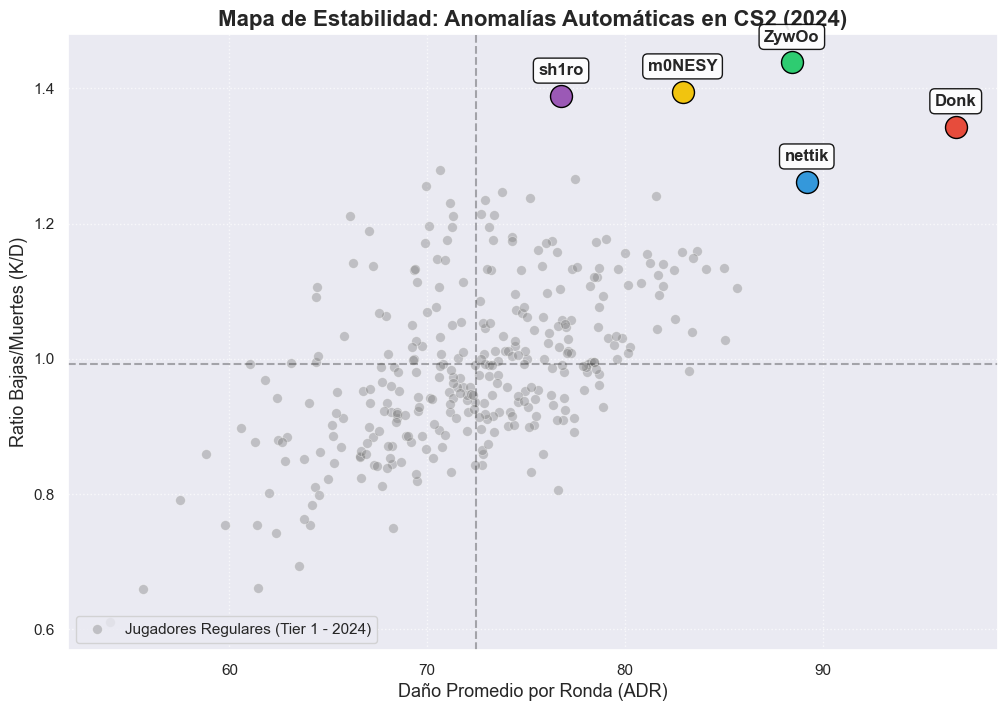

--- TOP 5 ANOMALÍAS AUTOMÁTICAS DETECTADAS EN 2024 ---


,Jugador,Mapas_Jugados,K/D_Historico,Promedio_ADR
299,"Donk (Danil Kryshkovets), RU",150,1.343561,96.734000
827,"nettik (Corey Browne), NZ",27,1.261838,89.200000
574,"ZywOo (Mathieu Herbaut), FR",138,1.438804,88.445652
789,"m0NESY (Ilya Osipov), RU",175,1.395169,82.918857
897,"sh1ro (Dmitry Sokolov), RU",155,1.388920,76.772903


In [25]:
# CELDA 13: Comparativa con un año estable (2024)
# En 2024 los jugadores ya tienen muchísimos mapas jugados, la muestra es sólida.

AÑO_ESTABLE = 2024

# 1. Filtramos los datos para 2024
df_2024 = perfiles_t1[perfiles_t1['Año'] == AÑO_ESTABLE].copy()

# 2. Buscamos automáticamente a la Élite Anómala de 2024
anomalias_2024 = df_2024[(df_2024['Anomalia_Sistemica'] == -1) & (df_2024['K/D_Historico'] > 1.05)]

# Elegimos al Top 5 más bestial (ordenado por ADR y luego K/D)
top_5_monstruos = anomalias_2024.sort_values(
    by=['Promedio_ADR', 'K/D_Historico'], ascending=[False, False]
).head(5)

plt.figure(figsize=(12, 8))

# 3. Graficamos el fondo gris de jugadores normales
sns.scatterplot(
    data=df_2024, 
    x='Promedio_ADR', 
    y='K/D_Historico', 
    color='gray', 
    alpha=0.4, 
    label=f'Jugadores Regulares (Tier 1 - {AÑO_ESTABLE})',
    s=50
)

# 4. Resaltamos al Top 5 detectado por la IA
colores = ['#e74c3c', '#3498db', '#2ecc71', '#f1c40f', '#9b59b6']

for (index, jugador), color in zip(top_5_monstruos.iterrows(), colores):
    x_val = jugador['Promedio_ADR']
    y_val = jugador['K/D_Historico']
    
    # Limpiamos el nombre para que se lea mejor (sacamos el país y nombre real)
    nick_limpio = jugador['Jugador'].split(' ')[0]
    
    # Dibujamos el punto gigante
    plt.scatter(x_val, y_val, color=color, s=250, edgecolor='black', zorder=5)
    
    # Le ponemos la etiqueta
    plt.annotate(
        nick_limpio, 
        (x_val, y_val), 
        textcoords="offset points", 
        xytext=(0,15), 
        ha='center', 
        fontsize=12, 
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9),
        zorder=10
    )

# Líneas promedio
promedio_adr = df_2024['Promedio_ADR'].mean()
promedio_kd = df_2024['K/D_Historico'].mean()
plt.axvline(promedio_adr, color='black', linestyle='--', alpha=0.3)
plt.axhline(promedio_kd, color='black', linestyle='--', alpha=0.3)

plt.title(f'Mapa de Estabilidad: Anomalías Automáticas en CS2 ({AÑO_ESTABLE})', fontsize=16, fontweight='bold')
plt.xlabel('Daño Promedio por Ronda (ADR)', fontsize=13)
plt.ylabel('Ratio Bajas/Muertes (K/D)', fontsize=13)
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

# Imprimir la tabla para que los profesores vean los números
print(f"--- TOP 5 ANOMALÍAS AUTOMÁTICAS DETECTADAS EN {AÑO_ESTABLE} ---")
display(top_5_monstruos[['Jugador', 'Mapas_Jugados', 'K/D_Historico', 'Promedio_ADR']])

--- ANÁLISIS MULTIDIMENSIONAL: 17 ANOMALÍAS GLOBALES DETECTADAS (2024) ---

🔫 LA ANOMALÍA AGRESIVA (Máximas Kills): Donk (Danil Kryshkovets), RU (Kills/Ronda: 19.27)
💀 LA ANOMALÍA NEGATIVA (Máximas Muertes): NickelBack (Alexey Trofimov), RU (Muertes/Ronda: 17.97)
🤝 LA ANOMALÍA DE SOPORTE (Máximas Asistencias): NickelBack (Alexey Trofimov), RU (Asistencias/Ronda: 6.52)
🛡️ LA ANOMALÍA DE SUPERVIVENCIA (Máximo KAST): Perfecto (Ilya Zalutskiy), RU (KAST: 78.20%)



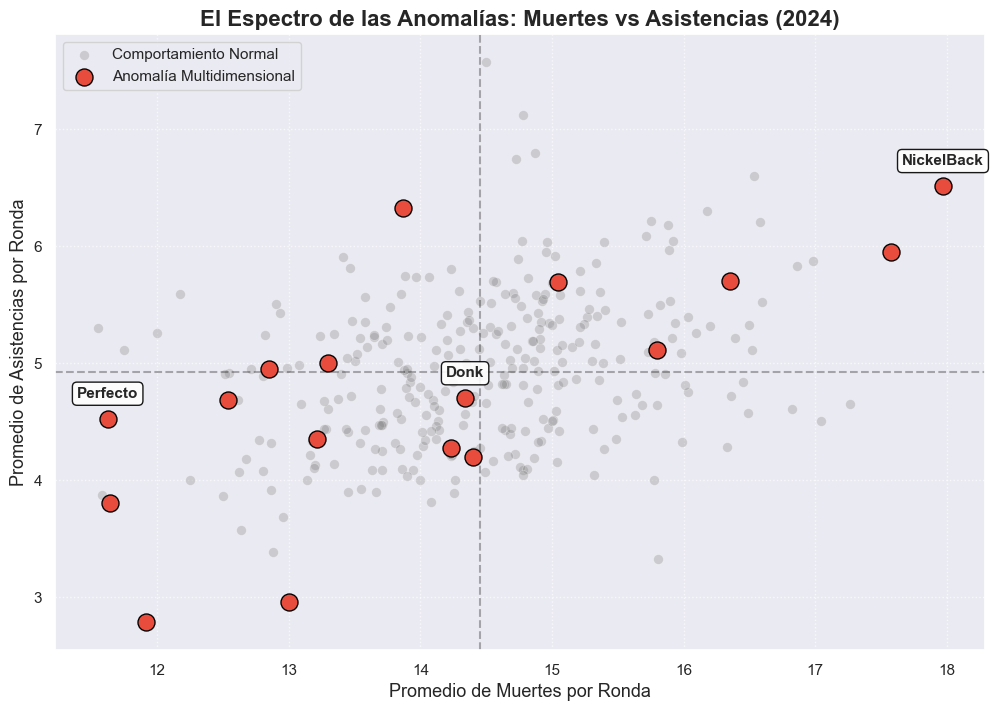

In [27]:
# CELDA 14: El Espectro Completo de Anomalías (Todas las variables sin filtros de "bondad")
import matplotlib.pyplot as plt
import seaborn as sns

AÑO_ESTABLE = 2024
df_2024 = perfiles_t1[perfiles_t1['Año'] == AÑO_ESTABLE].copy()

# 1. USAMOS TODAS LAS VARIABLES DISPONIBLES
features_totales = [
    'Promedio_Kills', 'Promedio_Deaths', 'Promedio_Assists', 
    'Promedio_ADR', 'Promedio_KAST', 'K/D_Historico'
]

X_total = df_2024[features_totales]

# 2. Entrenamos el modelo con una contaminación del 5% para buscar lo más bizarro
modelo_global = IsolationForest(n_estimators=300, contamination=0.05, random_state=42)
df_2024['Anomalia_Global'] = modelo_global.fit_predict(X_total)

# 3. Filtramos SOLO las anomalías (-1) SIN importar si son buenos o malos
anomalias_totales = df_2024[df_2024['Anomalia_Global'] == -1]

print(f"--- ANÁLISIS MULTIDIMENSIONAL: {len(anomalias_totales)} ANOMALÍAS GLOBALES DETECTADAS ({AÑO_ESTABLE}) ---\n")

# Extraemos los perfiles extremos para explicarlos
el_mas_asesino = anomalias_totales.loc[anomalias_totales['Promedio_Kills'].idxmax()]
el_que_mas_muere = anomalias_totales.loc[anomalias_totales['Promedio_Deaths'].idxmax()]
el_rey_asistencias = anomalias_totales.loc[anomalias_totales['Promedio_Assists'].idxmax()]
el_mas_pasivo = anomalias_totales.loc[anomalias_totales['Promedio_KAST'].idxmax()]

print(f"🔫 LA ANOMALÍA AGRESIVA (Máximas Kills): {el_mas_asesino['Jugador']} (Kills/Ronda: {el_mas_asesino['Promedio_Kills']:.2f})")
print(f"💀 LA ANOMALÍA NEGATIVA (Máximas Muertes): {el_que_mas_muere['Jugador']} (Muertes/Ronda: {el_que_mas_muere['Promedio_Deaths']:.2f})")
print(f"🤝 LA ANOMALÍA DE SOPORTE (Máximas Asistencias): {el_rey_asistencias['Jugador']} (Asistencias/Ronda: {el_rey_asistencias['Promedio_Assists']:.2f})")
print(f"🛡️ LA ANOMALÍA DE SUPERVIVENCIA (Máximo KAST): {el_mas_pasivo['Jugador']} (KAST: {el_mas_pasivo['Promedio_KAST']:.2f}%)\n")

# 4. GRAFICAMOS EL ESPECTRO (Asistencias vs Muertes para ver algo distinto al ADR vs K/D)
plt.figure(figsize=(12, 8))

# Jugadores normales (Gris)
normales = df_2024[df_2024['Anomalia_Global'] == 1]
sns.scatterplot(x='Promedio_Deaths', y='Promedio_Assists', data=normales, color='gray', alpha=0.3, label='Comportamiento Normal', s=50)

# Anomalías (Rojo)
sns.scatterplot(x='Promedio_Deaths', y='Promedio_Assists', data=anomalias_totales, color='#e74c3c', s=150, edgecolor='black', label='Anomalía Multidimensional', zorder=5)

# Etiquetar a las 4 anomalías extremas que detectamos arriba
extremes = [el_mas_asesino, el_que_mas_muere, el_rey_asistencias, el_mas_pasivo]
nombres_vistos = set()

for extremo in extremes:
    nick = extremo['Jugador'].split(' ')[0]
    if nick not in nombres_vistos:  # Evitar etiquetas duplicadas si un jugador lidera 2 cosas
        plt.annotate(
            nick, 
            (extremo['Promedio_Deaths'], extremo['Promedio_Assists']), 
            textcoords="offset points", xytext=(0,15), ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9), zorder=10
        )
        nombres_vistos.add(nick)

plt.axvline(df_2024['Promedio_Deaths'].mean(), color='black', linestyle='--', alpha=0.3)
plt.axhline(df_2024['Promedio_Assists'].mean(), color='black', linestyle='--', alpha=0.3)

plt.title('El Espectro de las Anomalías: Muertes vs Asistencias (2024)', fontsize=16, fontweight='bold')
plt.xlabel('Promedio de Muertes por Ronda', fontsize=13)
plt.ylabel('Promedio de Asistencias por Ronda', fontsize=13)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()